In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import svm, datasets
from sklearn.preprocessing import StandardScaler

In [27]:
# 导入鸢尾花数据集
iris = datasets.load_iris()
x = iris.data
y = iris.target
X = x[y < 2,:2]     # 仅选择2个特征，方便绘图比较
y = y[y < 2] 

In [28]:
# 通过归一化对数据进行无量纲化处理
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

In [29]:
# 导入模型
model = svm.SVC(C=1e9, kernel='linear')
model.fit(X, y)

SVC(C=1000000000.0, kernel='linear')

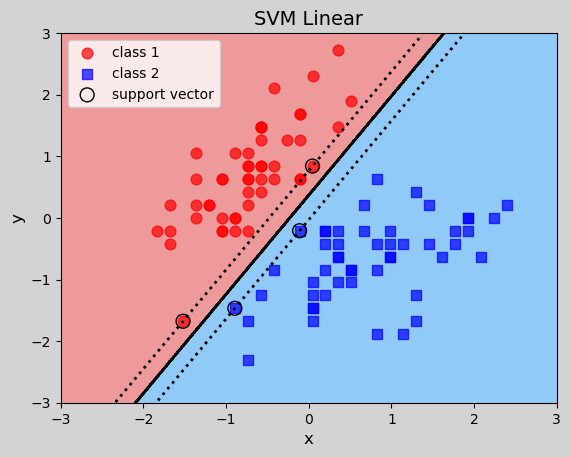

In [30]:
# 绘制网格
axis = [-3, 3, -3, 3]
xlist1 = np.linspace(axis[0], axis[1], int((axis[1] - axis[0]) * 100))
xlist2 = np.linspace(axis[2], axis[3], int((axis[3] - axis[2]) * 100))
XGrid1, XGrid2 = np.meshgrid(xlist1, xlist2)

# 计算正例分类线、负例分类线
w = model.coef_[0]
b = model.intercept_[0]
plot_x = np.linspace(axis[0], axis[1], 200)
up_y = -w[0] / w[1] * plot_x - b / w[1] + 1 / w[1]
down_y = -w[0] / w[1] * plot_x - b / w[1] - 1 / w[1]
up_index = (up_y >= axis[2]) & (up_y <= axis[3])
down_index = (down_y >= axis[2]) & (down_y <= axis[3])

# 预测并绘制结果
Z = model.predict(np.vstack([XGrid1.ravel(), XGrid2.ravel()]).T)
Z = Z.reshape(XGrid1.shape)

plt.figure('SVM Linear', facecolor='lightgray')
plt.title('SVM Linear', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.tick_params(labelsize=10)

# 绘制分类线
plt.plot(plot_x[up_index], up_y[up_index], c='black', linewidth=2, linestyle=':')
plt.plot(plot_x[down_index], down_y[down_index], c='black', linewidth=2, linestyle=':')

# 绘制超平面
plt.contourf(XGrid1, XGrid2, Z, cmap=ListedColormap(['#EF9A9A', '#FFF59D', '#90CAF9']))
plt.contour(XGrid1, XGrid2, Z, colors=('k',))

# 绘制类别1
plt.scatter(X[y == 0, 0], X[y == 0, 1], s=60, marker='o', alpha=0.7, label='class 1', c='r')

# 绘制类别2
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=60, marker='s', alpha=0.7, label='class 2', c='b')

# 绘制支持向量
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100, c='none', edgecolors='k', marker='o', label='support vector')
plt.legend()
plt.show()